In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
from torchvision import transforms as T

import pytorch_lightning as pl

from torchmetrics.classification import Accuracy
from torchvision.datasets import MNIST

from datetime import datetime


from xaikd import datasets, utils, attributors

from tqdm.notebook import tqdm

from zennit.attribution import Gradient
from zennit.composites import EpsilonGammaBox

In [2]:
!nproc

16


In [3]:
DEVICE = utils.get_device()
DEVICE

'cuda'

In [4]:
NUM_WORKERS = 16

In [5]:
ds_train = datasets.MultiTaskEMNISTFashionMNIST(
    train=True,
    root="../../datasets",
    transform=T.Compose(
        [
            T.ToTensor(),
            T.Normalize(
                0.5,
                0.5,
            ),
        ]
    )
)

ds_val = datasets.MultiTaskEMNISTFashionMNIST(
    train=False,
    root="../../datasets",
    transform=T.Compose(
        [
            T.ToTensor(),
            T.Normalize(
                0.5,
                0.5,
            ),
        ]
    )
)

In [6]:
TASK_NUM_CLASSES = ds_train.num_classes

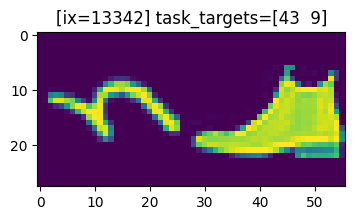

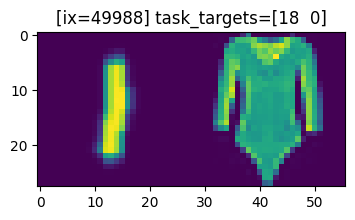

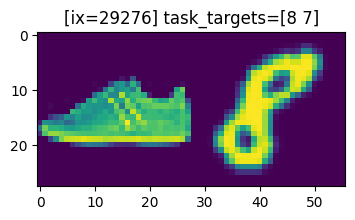

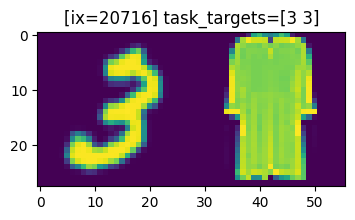

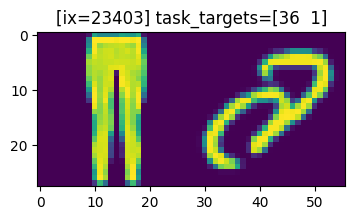

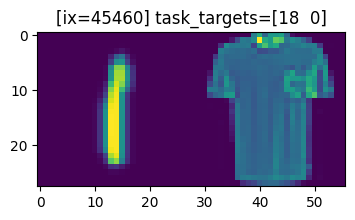

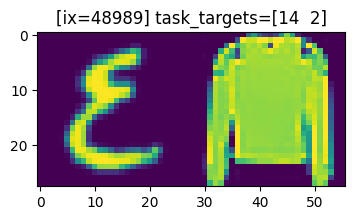

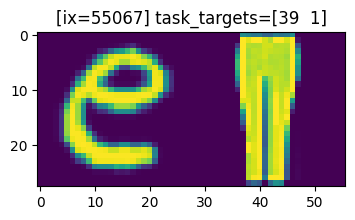

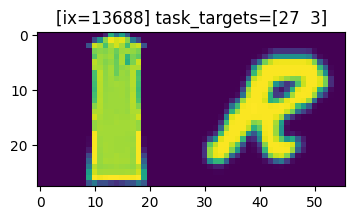

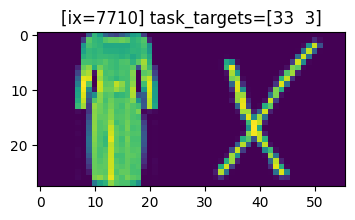

In [7]:
def ano():

    for ix in np.random.permutation(60000)[:10]:
        
        x, y = ds_train[ix]
    
        plt.figure(figsize=(2*2, 2))
        plt.imshow(x.squeeze())
        plt.title(f"[ix={ix}] task_targets={y}")
ano()

# Construct Model and Train

In [8]:
class CNN(nn.Module):
    def __init__(self, num_classes=10, d=256):
        super().__init__()
        self.conv1 = nn.Conv2d(kernel_size=3, out_channels=d, in_channels=1)
        self.act1 = nn.ReLU()
        self.max1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(kernel_size=3, out_channels=d, in_channels=d)
        self.act2 = nn.ReLU()
        self.max2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(kernel_size=3, out_channels=d, in_channels=d)
        self.act3 = nn.ReLU()
        
        self.avgpool = nn.AdaptiveAvgPool2d(output_size=1)
        
        self.fc_task_1 = nn.Linear(d, TASK_NUM_CLASSES[0])
        self.fc_task_2 = nn.Linear(d, TASK_NUM_CLASSES[1])

    def forward(self, x):
        x = self.act1(self.conv1(x))
        x = self.max1(x)

        x = self.act2(self.conv2(x))
        x = self.max2(x)

        x = self.act3(self.conv3(x))

        x = self.avgpool(x)
        x = torch.flatten(x, start_dim=1)
        out_task_1 = self.fc_task_1(x)
        out_task_2 = self.fc_task_2(x)

        return out_task_1, out_task_2
    
def ano():
    
    out = CNN()(torch.randn(7, 1, 28, 28*2))
    
    print(f"santity check")
ano()

santity check


In [9]:
from torchvision.models.resnet import resnet18
from torch import nn

In [10]:
resnet18(num_classes=10);

In [11]:
# class MutitaskHead(nn.Module):
#     def __init__(self, in_dims, task_num_classes):
#         super().__init__()

#         assert len(task_num_classes) == 2
        
#         self.fc_1 = nn.Linear(in_dims, task_num_classes[0])
#         self.fc_2 = nn.Linear(in_dims, task_num_classes[1])
#     def forward(self, x):
#         return self.fc_1(x), self.fc_2(x)
        
# def construct_resnet():

#     resnet = resnet18(num_classes=10)
#     # todo: get the actual value from conv1
#     resnet.conv1 = nn.Conv2d(
#         1, 64, kernel_size=7, stride=2, padding=3, bias=False
#     )
#     resnet.fc = MutitaskHead(512, TASK_NUM_CLASSES)

#     return resnet
    
# def ano():
    
#     out = construct_resnet()(torch.randn(7, 1, 28, 28*2))
    
#     print(f"santity check")
# ano()

In [12]:
class ModelWrapper(pl.LightningModule):
    def __init__(self, encoder, lr=1e-3, weight_decay=0.0):
        super().__init__()

        self.encoder = encoder
        
        self.weight_decay = weight_decay
        self.lr = lr

    def forward(self, x):
        embedding = self.encoder(x)
        return embedding

    def configure_optimizers(self):

        optimizer = torch.optim.Adam(
            self.parameters(), lr=self.lr, 
            # momentum=0.0, weight_decay=self.weight_decay
        )

        return optimizer

    def compute_metric(self, batch, prefix):

        x, y = batch

        arr_logits = self.encoder(x)

        loss = 0
        for tidx in range(2):
            y_task = y[:, tidx]
            logits_task = arr_logits[tidx]
            loss += 0.5*F.cross_entropy(
                logits_task, 
                y_task
            )

        return loss

    def training_step(self, train_batch, batch_idx):

        loss = self.compute_metric(train_batch, "train")

        self.log("train_loss", loss, on_epoch=True, prog_bar=True)
        return loss

    def summary_metric(self, prefix):

        metric = self.metrics[prefix]
        value = metric.compute()

        self.log(f"{prefix}_acc", value)

        metric.reset()

In [13]:
dl_train_noshuffle = DataLoader(
    ds_train,
    batch_size=64,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    shuffle=False,
    persistent_workers=True,
)

dl_test = DataLoader(
    ds_val,
    batch_size=64,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    shuffle=False,
    persistent_workers=True,
)

In [14]:
pl.seed_everything(1)

dl_train = DataLoader(
    ds_train,
    batch_size=64,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    prefetch_factor=2,
    persistent_workers=True
)


model  = CNN()

# model = construct_resnet()

trainer = pl.Trainer(
    max_epochs=100,
    accelerator=DEVICE,
)

trainer.fit(ModelWrapper(model), dl_train, dl_test)

[rank: 0] Global seed set to 1
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/usr/local/lib/python3.11/site-packages/pytorch_lightning/trainer/configuration_validator.py:70: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")
You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type | Params
---------------------------------
0 | encoder | CNN  | 1.2 M 
--------------------------

Training: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


In [15]:
model = model.to(DEVICE)

In [28]:
def estimate_task_acc(model, dl, task_id, verbose=False):
    metric = Accuracy(task="multiclass", num_classes=TASK_NUM_CLASSES[task_id])

    for x, y in tqdm(dl, disable=not verbose):
        task_logit = model(x.to(DEVICE))[task_id].detach().cpu()
        task_target = y[:, task_id]
        metric.update(task_logit, task_target)
    return float(metric.compute())

def compute_accs():
    
    stats = dict()
    
    for tidx in tqdm(range(2)):
        
        for label, dl in [
            ("train", dl_train_noshuffle),
            ("test", dl_test)
        ]:            
            stats[f"acc_task_{tidx}_{label}"] = estimate_task_acc(model, dl, tidx)
    
    return stats

ref_stats = compute_accs()
ref_stats

  0%|          | 0/2 [00:00<?, ?it/s]

{'acc_task_0_train': 0.9327499866485596,
 'acc_task_0_test': 0.8360000252723694,
 'acc_task_1_train': 0.9593499898910522,
 'acc_task_1_test': 0.8878999948501587}

In [17]:


class TaskSpecificHeadModel(nn.Module):
    def __init__(self, model, task_id: int):
        super().__init__()
        self.model = model
        self.task_id = task_id 

    def forward(self, x):
        return self.model(x)[self.task_id]

def make_attributor(model):
    
    low = torch.tensor([-1.])
    high = torch.tensor([1.])

    composite = EpsilonGammaBox(low=low, high=high, epsilon=0.0, gamma=0.1)

    return Gradient(model=model, composite=composite)


def sanity_check():

    task_id = 0
    logit_modifier = attributors.WinningClassEvidence(num_classes=TASK_NUM_CLASSES[task_id])
    task_specific_model = TaskSpecificHeadModel(model, task_id=task_id)
    with make_attributor(task_specific_model) as attributor:
        x = torch.randn((7, 1, 28, 28*2)).to(DEVICE)
        
        _ = attributor.forward(x, lambda logits: logit_modifier(logits, None))
    print("sanity_check: passed")

sanity_check()

sanity_check: passed


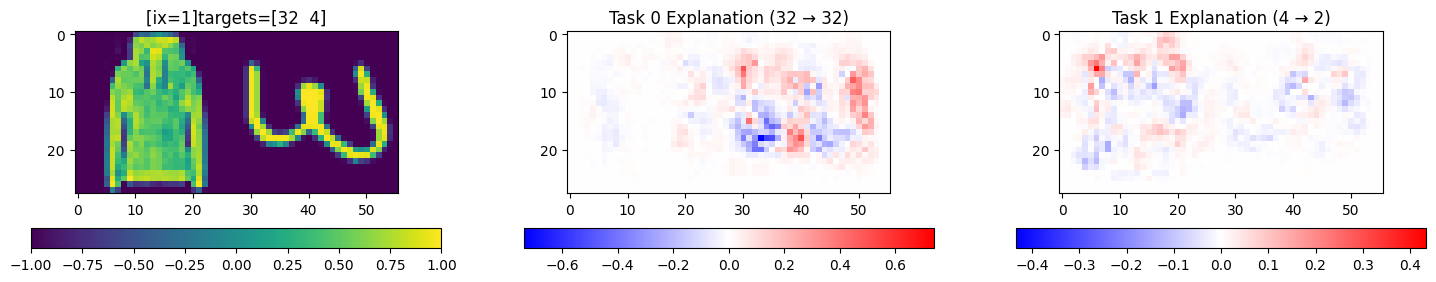

In [18]:
def viz_explain_tasks(sample_ix):

    ncols = 3
    plt.figure(figsize=(6*ncols, 3))

    x, y = ds_val[sample_ix]
    x = x.unsqueeze(0).to(DEVICE)

    plt.subplot(1, 3, 1)
    plt.title(f"[ix={sample_ix}]targets={y}")

    plt.imshow(x.detach().cpu().numpy().squeeze())
    plt.colorbar(location="bottom")
    for task_id in [0, 1]:
        task_specific_model = TaskSpecificHeadModel(model, task_id=task_id)
        
        with make_attributor(task_specific_model) as attributor:

            task_logits, heatmap = attributor.forward(
                x, 
                lambda logits: logits * F.one_hot(torch.tensor([y[task_id]]), num_classes=TASK_NUM_CLASSES[task_id]).to(logits.device)
            )

            task_logits = task_logits.detach().cpu().numpy()
            pred = np.argmax(task_logits)

            plt.subplot(1, ncols, task_id + 2)

            plt.title(f"Task {task_id} Explanation ({y[task_id]} → {pred})")

            heatmap = heatmap.cpu().detach().numpy().squeeze()
            vmax = np.abs(heatmap).max()
            plt.imshow(heatmap, cmap="bwr", vmin=-vmax, vmax=vmax)
            plt.colorbar(location="bottom")
    
viz_explain_tasks(1)

In [19]:
model

CNN(
  (conv1): Conv2d(1, 256, kernel_size=(3, 3), stride=(1, 1))
  (act1): ReLU()
  (max1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
  (act2): ReLU()
  (max2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
  (act3): ReLU()
  (avgpool): AdaptiveAvgPool2d(output_size=1)
  (fc_task_1): Linear(in_features=256, out_features=47, bias=True)
  (fc_task_2): Linear(in_features=256, out_features=10, bias=True)
)

In [20]:
LAYER = ["max1", "max2", "act3"][2]
LAYER

'act3'

In [21]:
def extract_activation_context(
    model: nn.Module,
    layer: str,
    data_loader: DataLoader,
    task_id: int,
    logit_modifier: attributors.LogitModifier,
    rng: np.random.Generator,
    device="cpu",
    number_of_selected_spatial_locations=20,
    strict_mode=False,
    verbose=False
):
    arr_act = []
    arr_ctx = []

    try:
        module, hook = utils.interceptor.attach_hook_intercept_layer_output(
            model, layer, should_retain_grad=True, detach_output=False
        )

        task_specific_head = TaskSpecificHeadModel(model, task_id=task_id)

        with make_attributor(task_specific_head) as attributor:
            for batch in tqdm(data_loader, desc="extract act ctx"):
                x, y = batch
                x = x.to(device)

                _ = attributor.forward(x, lambda logits: logit_modifier(logits, y))

                act = utils.interceptor.get_output(module)

                assert act.grad is not None
                rel = act.grad

                output_dimensions = act.shape[1:]

                ctx = torch.where(act.abs() > 0, rel / act, 0)

                if strict_mode:
                    np.testing.assert_allclose(
                        (act * ctx).detach().cpu().numpy(),
                        rel.detach().cpu().numpy(),
                        atol=1e-6,
                    )

                assert ctx.shape == act.shape

                act = act.detach().cpu().numpy()
                ctx = ctx.detach().cpu().numpy()

                selected_act, selected_ctx = utils.subsample_tensors(
                    act,
                    ctx,
                    num_locations=number_of_selected_spatial_locations,
                    rng=rng,
                )
                arr_act.append(selected_act)
                arr_ctx.append(selected_ctx)

    finally:
        hook.remove()

    print(f"{layer}: output-dims={output_dimensions}")

    arr_act = np.vstack(arr_act)
    arr_ctx = np.vstack(arr_ctx)

    return arr_act, arr_ctx


def extract_act_grad(model, dl, task_id):
    
    
    return extract_activation_context(
        model=model,
        layer=LAYER,
        data_loader=dl_train_noshuffle,
        task_id=task_id,
        logit_modifier=attributors.WinningClassEvidence(num_classes=TASK_NUM_CLASSES[task_id]),
        # logit_modifier=attributors.ALlClassesEvidence(num_classes=10),

        rng=np.random.default_rng(seed=1),
        device=DEVICE
    )

extract_act_grad(model, dl_train_noshuffle, 0)

extract act ctx:   0%|          | 0/938 [00:00<?, ?it/s]

act3: output-dims=torch.Size([256, 3, 10])


(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], dtype=float32),
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], dtype=float32))

In [22]:
def sanity_check():
    arr_act, _ = extract_act_grad(model, dl_train_noshuffle, 0)
    
    for tidx in [1]:
        arr_act_other, _ = extract_act_grad(model, dl_train_noshuffle, tidx)
        np.testing.assert_allclose(
            arr_act_other,
            arr_act
        )
        print(f"arr_act(T0) == arr_act(T{tidx})")
    print("all passed!")
# sanity_check()

In [23]:
def _solve_eigvecs(cov, sort_func=lambda x: x):
    eigvals, eigvecs = np.linalg.eigh(cov)

    assert len(eigvals.shape) == 1

    indices = np.argsort(-sort_func(eigvals))
    eigvals = eigvals[indices]
    eigvecs = eigvecs[:, indices]

    return eigvecs

def estimate_basis(basis_name, arr_act, arr_ctx):
    if basis_name == "pca":
        cov = arr_act.T @ arr_act
        eigvecs = _solve_eigvecs(cov)
        return eigvecs
    
    elif basis_name == "prca":
        cov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        eigvecs = _solve_eigvecs(cov, sort_func=np.abs)
        return eigvecs
    else:
        raise

        
def construct_fh(Uk):
    def fh(mod, inp, outp):
        return F.conv2d(
            outp,
            (Uk@Uk.T).unsqueeze(2).unsqueeze(3)
        )
    return fh

def compute_task_acc_at_k(model, task_id, arr_ks):
    arr_act, arr_ctx = extract_act_grad(model, dl_train_noshuffle, task_id)
    arr_stat_rows = []
    
    module = getattr(model, LAYER)
    
    for basis_name in ["pca", "prca"]:
        U = estimate_basis(basis_name, arr_act, arr_ctx)
        for k in tqdm(arr_ks):
            Uk = torch.from_numpy(U[:, :k]).to(DEVICE)
            row = dict(
                task_id=task_id, 
                basis_name=basis_name,
                k=k,   
            )
            try:
                hook = module.register_forward_hook(construct_fh(Uk))
                
                for label, dl in [
                    ("train", dl_train_noshuffle),
                    ("test", dl_test)
                ]:
                    row[f"acc_{label}"] = estimate_task_acc(model, dl, task_id)
                
            finally:
                hook.remove()
            arr_stat_rows.append(row)
            
    df = pd.DataFrame(arr_stat_rows)
    
    return df

compute_task_acc_at_k(model, task_id=0, arr_ks=[1, 128, 256])

extract act ctx:   0%|          | 0/938 [00:00<?, ?it/s]

act3: output-dims=torch.Size([256, 3, 10])


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

,task_id,basis_name,k,acc_train,acc_test
0,0,pca,1,0.022133,0.0233
1,0,pca,128,0.932817,0.8360
2,0,pca,256,0.932817,0.8360
3,0,prca,1,0.022950,0.0221
4,0,prca,128,0.932817,0.8360
5,0,prca,256,0.932817,0.8360


In [24]:
model

CNN(
  (conv1): Conv2d(1, 256, kernel_size=(3, 3), stride=(1, 1))
  (act1): ReLU()
  (max1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
  (act2): ReLU()
  (max2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
  (act3): ReLU()
  (avgpool): AdaptiveAvgPool2d(output_size=1)
  (fc_task_1): Linear(in_features=256, out_features=47, bias=True)
  (fc_task_2): Linear(in_features=256, out_features=10, bias=True)
)

In [25]:
def get_dims(layer):
    return {
        "max1": 256,
        "max2": 256,
        "act3": 256,
    }[layer]

# Accuracy Curves

extract act ctx:   0%|          | 0/938 [00:00<?, ?it/s]

act3: output-dims=torch.Size([256, 3, 10])


  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

extract act ctx:   0%|          | 0/938 [00:00<?, ?it/s]

act3: output-dims=torch.Size([256, 3, 10])


  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

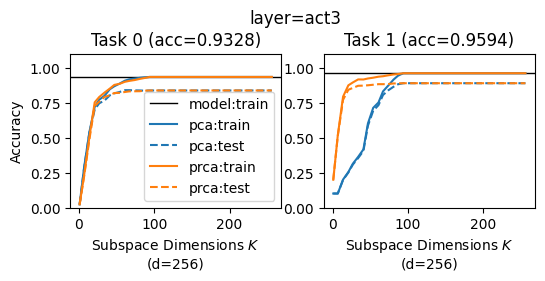

In [26]:
def viz():
    
    arr_task_ids = np.arange(2)
    ncols = arr_task_ids.shape[0]
    plt.figure(figsize=(3*ncols, 2))
    
    # d = model.lin1.weight.shape[0]
    d = get_dims(LAYER)
    arr_ks = np.linspace(1, d // 2, 20).astype(int).tolist() + [d]
    
    plt.suptitle(f"layer={LAYER}", y=1.1)
    
    for task_id in arr_task_ids:
        plt.subplot(1, ncols, task_id+1)
        
        df = compute_task_acc_at_k(model, task_id=task_id, arr_ks=arr_ks)
        
        for basis_name in ["pca", "prca"]:
            _df = df[df.basis_name == basis_name]
            
            if basis_name == "pca":
                
                ref = _df.acc_train.values[-1]
                plt.title(f"Task {task_id} (acc={ref:.4f})")

                plt.axhline(
                    ref,
                    ls="-",
                    lw=1,
                    color="k",
                    label="model:train"
                )
            
            for label in ["train", "test"]:
                
                if label == "test":
                    color = plt.gca().lines[-1].get_color()
                    ls = "--"
                else:
                    color = None
                    ls = "-"
        
                plt.plot(
                    _df.k,
                    _df[f"acc_{label}"],
                    color=color,
                    ls=ls,
                    label=f"{basis_name}:{label}"
                )
        plt.ylim([0.0, 1.1])
        if task_id == 0:
            plt.legend()
            plt.ylabel("Accuracy")
        plt.xlabel(f"Subspace Dimensions $K$\n(d={d})")
viz()

In [27]:
print(f"Finished at {datetime.now()}")

Finished at 2024-11-29 19:26:58.746622
